In [33]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from datetime import datetime 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import contextily as cnx
import matplotlib.pyplot as plt
from datetime import date
import re
from rasterstats import zonal_stats
import rasterio
import os
import glob
from tqdm import tqdm
from shapely.geometry import box
import math
from shapely.geometry import LineString
from shapely import wkt


<h2> Pair Matching <h2> 

<h5> Getting footprint pairs within a max distance of 40 m with information from pre and post fire. <h5>

In [34]:
# Folder where your batch files are stored
BATCH_FOLDER = "GEDI_Fire_Dates"
PAIRS_FOLDER = "GEDI_Pairs"
PAIRS_BATCH_FOLDER = "GEDI_Pairs_Batches"
os.makedirs(PAIRS_FOLDER, exist_ok=True)

# Collect all batch files
batch_files = glob.glob(os.path.join(BATCH_FOLDER, "*.gpkg"))
print(f"Found {len(batch_files)} batch files.")


Found 26 batch files.


In [35]:
test = gpd.read_file("GEDI_Fire_Dates/GEDI_Fire_Dates_0000026880-0000026880_batch2.gpkg")
print(test.columns)

Index(['latitude', 'longitude', 'time', 'shot_number',
       'digital_elevation_model', 'elev_lowestmode', 'cover', 'pai',
       'l4_quality_flag', 'predictor_limit_flag', 'agbd', 'agbd_pi_lower',
       'agbd_pi_upper', 'agbd_se', 'wsci', 'rh_50', 'rh_90', 'rh_98',
       'tile_id', 'gedi_point_wkt', 'fire_count', 'first_fire_date',
       'last_fire_date', 'fire_dates_str', 'geometry'],
      dtype='str')


In [36]:
test.head()

,latitude,longitude,time,shot_number,digital_elevation_model,elev_lowestmode,cover,pai,l4_quality_flag,predictor_limit_flag,...,rh_50,rh_90,rh_98,tile_id,gedi_point_wkt,fire_count,first_fire_date,last_fire_date,fire_dates_str,geometry
0,-8.158494,-51.783984,2019-09-19,43621100100092660,492.670105,475.238373,0.862027,3.963002,1,255,...,11.53,21.350000,24.639999,362,POINT (-51.783984 -8.158494),1,2024-09-01,2024-09-01,2024-09-01,"POLYGON ((-51.78378 -8.15851, -51.78378 -8.158..."
1,-8.158075,-51.783681,2019-09-19,43621100100092661,491.815125,476.123566,0.911931,4.862261,1,255,...,19.02,30.450001,33.000000,362,POINT (-51.783681 -8.158075),1,2024-09-01,2024-09-01,2024-09-01,"POLYGON ((-51.78348 -8.1581, -51.78348 -8.1581..."
2,-8.157945,-51.789909,2019-06-13,28431100400305647,590.630981,586.932739,0.667491,2.202523,1,255,...,7.19,15.950000,19.250000,362,POINT (-51.789909 -8.157945),1,2024-08-01,2024-08-01,2024-08-01,"POLYGON ((-51.7897 -8.15797, -51.78971 -8.1579..."
3,-8.157818,-51.790456,2019-09-19,43620800100093952,601.555481,589.992859,0.875588,4.170025,1,255,...,13.74,18.500000,21.350000,362,POINT (-51.790456 -8.157818),1,2024-08-01,2024-08-01,2024-08-01,"POLYGON ((-51.79025 -8.15784, -51.79025 -8.157..."
4,-8.157655,-51.783378,2019-09-19,43621100100092662,493.010529,476.567078,0.806921,3.290267,1,255,...,10.86,19.139999,25.020000,362,POINT (-51.783378 -8.157655),1,2024-09-01,2024-09-01,2024-09-01,"POLYGON ((-51.78317 -8.15768, -51.78318 -8.157..."


In [37]:
# Convert comma-separated date string into list of datetime objects.

def parse_fire_dates_str(fire_dates_str):
    """Convert comma-separated date string into list of datetime objects."""
    if not fire_dates_str or fire_dates_str.strip() == "":
        return []
    return [pd.to_datetime(d, errors="coerce") for d in fire_dates_str.split(",") if d]

In [38]:
def row_to_suffixed_dict(row, suffix, exclude_cols=None):
    """
    Copy all attributes from a GeoSeries row into a dict with a suffix.
    Example: agbd -> agbd_1
    """
    if exclude_cols is None:
        exclude_cols = set()

    out = {}
    for col in row.index:
        if col in exclude_cols:
            continue
        out[f"{col}_{suffix}"] = row[col]
    return out


def get_close_pairs_with_fire(gdf_proj, max_distance=40):
    gdf_proj = gdf_proj.copy()

    # Use the correct time column from your new GEDIdb files
    time_col = "time" if "time" in gdf_proj.columns else "gedi_time"
    gdf_proj[time_col] = pd.to_datetime(gdf_proj[time_col], errors="coerce")

    # Centroids for distance calculations
    centroids = gdf_proj.geometry.centroid
    coords = np.column_stack([centroids.x.values, centroids.y.values])

    # KD-tree
    tree = cKDTree(coords)
    dist_matrix = tree.sparse_distance_matrix(
        tree,
        max_distance=max_distance,
        output_type="coo_matrix"
    )

    close_pairs = [
        (i, j, d)
        for i, j, d in zip(dist_matrix.row, dist_matrix.col, dist_matrix.data)
        if i < j
    ]

    records = []

    for i, j, d in tqdm(close_pairs, desc="Finding footprint pairs"):
        fi = gdf_proj.iloc[i]
        fj = gdf_proj.iloc[j]

        t_i = pd.to_datetime(fi[time_col], errors="coerce")
        t_j = pd.to_datetime(fj[time_col], errors="coerce")

        if pd.isna(t_i) or pd.isna(t_j):
            continue

        # Assign pre-fire / post-fire roles by time
        if t_i <= t_j:
            pre, post = fi, fj
            pre_idx, post_idx = i, j
            pre_time, post_time = t_i, t_j
        else:
            pre, post = fj, fi
            pre_idx, post_idx = j, i
            pre_time, post_time = t_j, t_i

        # Fire dates from either footprint
        fire_dates_pre = parse_fire_dates_str(pre.fire_dates_str) if "fire_dates_str" in pre.index else []
        fire_dates_post = parse_fire_dates_str(post.fire_dates_str) if "fire_dates_str" in post.index else []
        all_fire_dates = fire_dates_pre + fire_dates_post

        between = [fd for fd in all_fire_dates if pd.notnull(fd) and pre_time < fd <= post_time]

        fire_date = min(between) if between else None
        post_fire_months = None
        if fire_date is not None:
            post_fire_months = (post_time.year - fire_date.year) * 12 + (post_time.month - fire_date.month)

        # Pair-level metadata
        record = {
            "index_1": pre_idx,
            "index_2": post_idx,
            "distance_m": d,
            "fire": fire_date is not None,
            "fire_date": fire_date,
            "post_fire_months": post_fire_months,

            # explicit geometry columns for each footprint
            "geometry_1": pre.geometry,
            "geometry_2": post.geometry,

            # active geometry for the pair
            "pair_line": LineString([pre.geometry.centroid, post.geometry.centroid]),
        }

        # Copy every other attribute from each footprint
        record.update(row_to_suffixed_dict(pre, suffix=1, exclude_cols={"geometry"}))
        record.update(row_to_suffixed_dict(post, suffix=2, exclude_cols={"geometry"}))

        # Optional derived metric
        if "agbd" in pre.index and "agbd" in post.index:
            record["delta_agbd"] = pre["agbd"] - post["agbd"]
        else:
            record["delta_agbd"] = None

        records.append(record)

    pairs_gdf = gpd.GeoDataFrame(records, geometry="pair_line", crs=gdf_proj.crs).sort_values("distance_m")
    return pairs_gdf



In [39]:

def reproject_aux_geom_column_to_wkt(df, col, src_crs, dst_crs="EPSG:4326"):
    """Reproject a non-active geometry column (shapely objects) and store as WKT."""
    if col not in df.columns or df.empty:
        return df

    # Build a temporary GeoSeries from the object column
    gs = gpd.GeoSeries(df[col], crs=src_crs)

    # Reproject and write back as WKT text (explicit and stable in GPKG)
    gs_ll = gs.to_crs(dst_crs)
    df[col] = gs_ll.to_wkt()
    return df


In [40]:
# Choose a single CRS for the final merged file.
# For sharing/interop, EPSG:4326 is fine. If you prefer projected for the final output,

COMMON_CRS = "EPSG:4326"

all_pairs_reproj = []

for f in tqdm(batch_files, desc="Processing batches"):
    try:
        gdf = gpd.read_file(f)
        if gdf.empty:
            print(f"Skipping empty file: {f}")
            continue

        # Project to local UTM for accurate distances
        utm_crs = gdf.estimate_utm_crs()
        gdf_proj = gdf.to_crs(utm_crs)

        # Compute pairs in UTM
        pairs = get_close_pairs_with_fire(gdf_proj, max_distance=40)

        if pairs.empty:
            print(f"No pairs found in: {os.path.basename(f)}")
            continue

        # Track source
        pairs["source_file"] = os.path.basename(f)

        # Record the CRS used for distance + original aux geometries (useful for audit)
        pairs["pairing_crs"] = str(pairs.crs)  # e.g., EPSG:32722

        # Reproject auxiliary geometry columns to lat/lon BEFORE saving
        pairs = reproject_aux_geom_column_to_wkt(pairs, "geometry_1", src_crs=pairs.crs, dst_crs=COMMON_CRS)
        pairs = reproject_aux_geom_column_to_wkt(pairs, "geometry_2", src_crs=pairs.crs, dst_crs=COMMON_CRS)

        # Optional explicit metadata for downstream users
        pairs["geometry_crs_1"] = COMMON_CRS
        pairs["geometry_crs_2"] = COMMON_CRS

        # Reproject active geometry (pair_line) to common CRS
        pairs_reproj = pairs.to_crs(COMMON_CRS)

        # Save intermediate per-batch pairs (optional, useful for recovery)
        intermediate_out = os.path.join(PAIRS_BATCH_FOLDER, f"pairs_{os.path.splitext(os.path.basename(f))[0]}.gpkg")
        pairs.to_file(intermediate_out, driver="GPKG")

        # Reproject pairs to a single common CRS for concatenation
        pairs_reproj = pairs.to_crs(COMMON_CRS)
        all_pairs_reproj.append(pairs_reproj)

    except Exception as e:
        print(f"Error processing {f}: {e}")



Processing batches: 100%|██████████| 26/26 [03:36<00:00,  8.32s/it]


In [41]:
OUTPUT_FILE = os.path.join(PAIRS_FOLDER, "GEDI_Footprint_Pairs_All_50.gpkg")

# Collect all .gpkg files in GEDI_Pairs
pair_files = sorted(glob.glob(os.path.join(PAIRS_BATCH_FOLDER, "*.gpkg")))
print(f"Found {len(pair_files)} pair files.")

all_pairs = []

for f in pair_files:
    gdf = gpd.read_file(f)

    if gdf.empty:
        print(f"Skipping empty file: {f}")
        continue

    # Add source file column for traceability
    gdf["source_file"] = os.path.basename(f)

    # Reproject to a common CRS
    gdf = gdf.to_crs("EPSG:4326")
    all_pairs.append(gdf)

if all_pairs:
    pairs_all = gpd.GeoDataFrame(
        pd.concat(all_pairs, ignore_index=True),
        geometry="geometry",
        crs="EPSG:4326"
    )

    # Drop extra geometry-type columns before saving
    cols_to_drop = [col for col in ["geometry_1", "geometry_2"] if col in pairs_all.columns]
    pairs_all = pairs_all.drop(columns=cols_to_drop)

    # Reorder and keep only the columns you want
    columns_to_keep = [
        'index_1', 'index_2', 'distance_m', 'fire', 'time_1', 'fire_date', 'time_2',
        'agbd_1', 'agbd_2', 'delta_agbd',
        'rh_98_1', 'rh_98_2', 'rh_90_1', 'rh_90_2', 'rh_50_1', 'rh_50_2',
        'cover_1', 'cover_2', 'pai_1', 'pai_2', 'wsci_1', 'wsci_2',
        'agbd_pi_lower_1', 'agbd_pi_upper_1', 'agbd_se_1',
        'agbd_pi_lower_2', 'agbd_pi_upper_2', 'agbd_se_2',
        'first_fire_date_1', 'first_fire_date_2',
        'last_fire_date_1', 'last_fire_date_2',
        'fire_dates_str_1', 'fire_dates_str_2',
        'fire_count_1', 'fire_count_2',
        'gedi_point_wkt_1', 'gedi_point_wkt_2',
        'geometry_1_wkt', 'geometry_crs_1', 'geometry_2_wkt','geometry_crs_2',
        'pairing_crs', 
        'shot_number_1', 'shot_number_2',
        'geometry'
    ]

    columns_to_keep = [col for col in columns_to_keep if col in pairs_all.columns]
    pairs_all = pairs_all[columns_to_keep].copy()

    # Convert datetime columns to strings for safer GeoPackage export
    datetime_cols = [
        "time_1", "fire_date", "time_2",
        "first_fire_date_1", "first_fire_date_2",
        "last_fire_date_1", "last_fire_date_2"
    ]

    for col in datetime_cols:
        if col in pairs_all.columns:
            pairs_all[col] = pd.to_datetime(pairs_all[col], errors="coerce")
            pairs_all[col] = pairs_all[col].dt.strftime("%Y-%m-%d %H:%M:%S")

    pairs_all.to_file(OUTPUT_FILE, driver="GPKG")
    print(f"✅ Merged {len(pair_files)} files into {OUTPUT_FILE} with {len(pairs_all)} pairs total.")

else:
    print("No pair files found to merge.")


Found 26 pair files.
✅ Merged 26 files into GEDI_Pairs/GEDI_Footprint_Pairs_All_50.gpkg with 72387 pairs total.


In [42]:
print(gdf.columns)

Index(['index_1', 'index_2', 'distance_m', 'fire', 'fire_date',
       'post_fire_months', 'geometry_1', 'geometry_2', 'latitude_1',
       'longitude_1', 'time_1', 'shot_number_1', 'digital_elevation_model_1',
       'elev_lowestmode_1', 'cover_1', 'pai_1', 'l4_quality_flag_1',
       'predictor_limit_flag_1', 'agbd_1', 'agbd_pi_lower_1',
       'agbd_pi_upper_1', 'agbd_se_1', 'wsci_1', 'rh_50_1', 'rh_90_1',
       'rh_98_1', 'tile_id_1', 'gedi_point_wkt_1', 'fire_count_1',
       'first_fire_date_1', 'last_fire_date_1', 'fire_dates_str_1',
       'latitude_2', 'longitude_2', 'time_2', 'shot_number_2',
       'digital_elevation_model_2', 'elev_lowestmode_2', 'cover_2', 'pai_2',
       'l4_quality_flag_2', 'predictor_limit_flag_2', 'agbd_2',
       'agbd_pi_lower_2', 'agbd_pi_upper_2', 'agbd_se_2', 'wsci_2', 'rh_50_2',
       'rh_90_2', 'rh_98_2', 'tile_id_2', 'gedi_point_wkt_2', 'fire_count_2',
       'first_fire_date_2', 'last_fire_date_2', 'fire_dates_str_2',
       'delta_agbd', 's

In [43]:
# Concatenate all
if all_pairs:
    pairs_all = gpd.GeoDataFrame(
        pd.concat(all_pairs, ignore_index=True),
        geometry="geometry",
        crs="EPSG:4326"
    )

    # Explicitly convert all date/time columns to plain strings
    datetime_cols = [
        "time_1",
        "time_2",
        "fire_date",
        "first_fire_date_1",
        "first_fire_date_2",
        "last_fire_date_1",
        "last_fire_date_2",
    ]

    for col in datetime_cols:
        if col in pairs_all.columns:
            pairs_all[col] = pd.to_datetime(pairs_all[col], errors="coerce", utc=False)
            pairs_all[col] = pairs_all[col].astype("string")
            pairs_all.loc[pairs_all[col].notna(), col] = pd.to_datetime(
                pairs_all.loc[pairs_all[col].notna(), col],
                errors="coerce"
            ).dt.strftime("%Y-%m-%d %H:%M:%S")

    # Extra safety: convert any remaining object column containing Timestamp values to string
    for col in pairs_all.columns:
        if col == pairs_all.geometry.name:
            continue
        if pairs_all[col].dtype == "object":
            sample = pairs_all[col].dropna().head(5)
            if len(sample) > 0 and any(isinstance(v, (pd.Timestamp, datetime)) for v in sample):
                pairs_all[col] = pd.to_datetime(pairs_all[col], errors="coerce").dt.strftime("%Y-%m-%d %H:%M:%S")

    pairs_all.to_file(OUTPUT_FILE, driver="GPKG")
    print(f"✅ Merged {len(pair_files)} files into {OUTPUT_FILE} with {len(pairs_all)} pairs total.")
else:
    print("No pair files found to merge.")



✅ Merged 26 files into GEDI_Pairs/GEDI_Footprint_Pairs_All_50.gpkg with 72387 pairs total.


In [44]:
pairs_all = gpd.read_file('GEDI_Pairs/GEDI_Footprint_Pairs_All_50.gpkg')
pairs_all.head()

,index_1,index_2,distance_m,fire,fire_date,post_fire_months,geometry_1,geometry_2,latitude_1,longitude_1,...,fire_count_2,first_fire_date_2,last_fire_date_2,fire_dates_str_2,delta_agbd,source_file,pairing_crs,geometry_crs_1,geometry_crs_2,geometry
0,33041,33042,0.141145,False,NaN,NaN,"POLYGON ((-50.346164 -3.529459, -50.346166 -3....","POLYGON ((-50.346162 -3.529459, -50.346165 -3....",-3.529439,-50.346367,...,1,2024-11-01 00:00:00,2024-11-01 00:00:00,2024-11-01,315.345947,pairs_GEDI_Fire_Dates_0000000000-0000026880_ba...,EPSG:32722,EPSG:4326,EPSG:4326,"LINESTRING (-50.34637 -3.52944, -50.34637 -3.5..."
1,23130,23131,0.307553,False,NaN,NaN,"POLYGON ((-50.777077 -3.292632, -50.77708 -3.2...","POLYGON ((-50.777077 -3.292629, -50.77708 -3.2...",-3.292612,-50.777280,...,1,2022-12-01 00:00:00,2022-12-01 00:00:00,2022-12-01,49.771812,pairs_GEDI_Fire_Dates_0000000000-0000026880_ba...,EPSG:32722,EPSG:4326,EPSG:4326,"LINESTRING (-50.77728 -3.29261, -50.77728 -3.2..."
2,38677,38678,0.417066,False,NaN,NaN,"POLYGON ((-50.755643 -3.322927, -50.755645 -3....","POLYGON ((-50.755642 -3.322924, -50.755645 -3....",-3.322907,-50.755846,...,2,2020-09-01 00:00:00,2021-11-01 00:00:00,"2020-09-01,2021-11-01",-123.445259,pairs_GEDI_Fire_Dates_0000000000-0000026880_ba...,EPSG:32722,EPSG:4326,EPSG:4326,"LINESTRING (-50.75585 -3.32291, -50.75584 -3.3..."
3,38651,38652,0.483623,False,NaN,NaN,"POLYGON ((-50.751767 -3.328401, -50.75177 -3.3...","POLYGON ((-50.751765 -3.328398, -50.751768 -3....",-3.328381,-50.751970,...,1,2021-12-01 00:00:00,2021-12-01 00:00:00,2021-12-01,-16.410385,pairs_GEDI_Fire_Dates_0000000000-0000026880_ba...,EPSG:32722,EPSG:4326,EPSG:4326,"LINESTRING (-50.75197 -3.32838, -50.75197 -3.3..."
4,38680,38679,0.530041,False,NaN,NaN,"POLYGON ((-50.749629 -3.322183, -50.749632 -3....","POLYGON ((-50.749628 -3.322188, -50.749631 -3....",-3.322163,-50.749832,...,1,2021-11-01 00:00:00,2021-11-01 00:00:00,2021-11-01,-0.629320,pairs_GEDI_Fire_Dates_0000000000-0000026880_ba...,EPSG:32722,EPSG:4326,EPSG:4326,"LINESTRING (-50.74983 -3.32216, -50.74983 -3.3..."


In [45]:
pairs_fire = pairs_all[pairs_all["fire"].fillna(False).astype(bool)].copy()

print(f"Total pairs: {len(pairs_all)}")
print(f"Pairs with fire == True: {len(pairs_fire)}")



Total pairs: 72387
Pairs with fire == True: 7870


Total pairs: 7870
Pairs with valid delta_agbd: 7870
Pairs with delta_agbd > 0: 4889
Pairs with delta_agbd <= 0: 2981


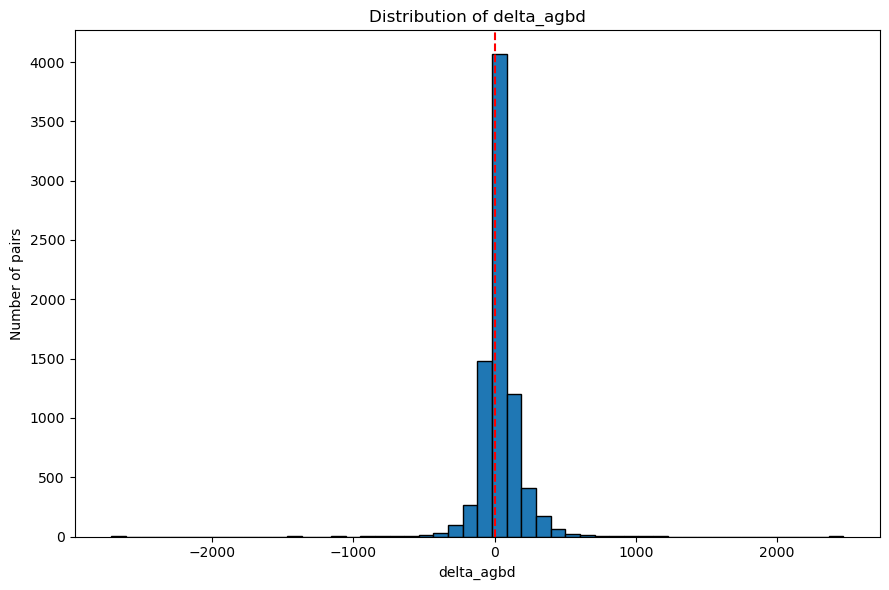

In [46]:
# Make sure delta_agbd is numeric
pairs_fire["delta_agbd"] = pd.to_numeric(pairs_fire["delta_agbd"], errors="coerce")

# Summary counts
total_fire_pairs = len(pairs_fire)
valid_delta = pairs_fire["delta_agbd"].notna().sum()
positive_delta = (pairs_fire["delta_agbd"] > 0).sum()
zero_or_negative_delta = (pairs_fire["delta_agbd"] <= 0).sum()

print(f"Total pairs: {total_fire_pairs}")
print(f"Pairs with valid delta_agbd: {valid_delta}")
print(f"Pairs with delta_agbd > 0: {positive_delta}")
print(f"Pairs with delta_agbd <= 0: {zero_or_negative_delta}")

# Histogram
plt.figure(figsize=(9, 6))
plt.hist(pairs_fire["delta_agbd"].dropna(), bins=50, edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("delta_agbd")
plt.ylabel("Number of pairs")
plt.title("Distribution of delta_agbd")
plt.tight_layout()
plt.show()


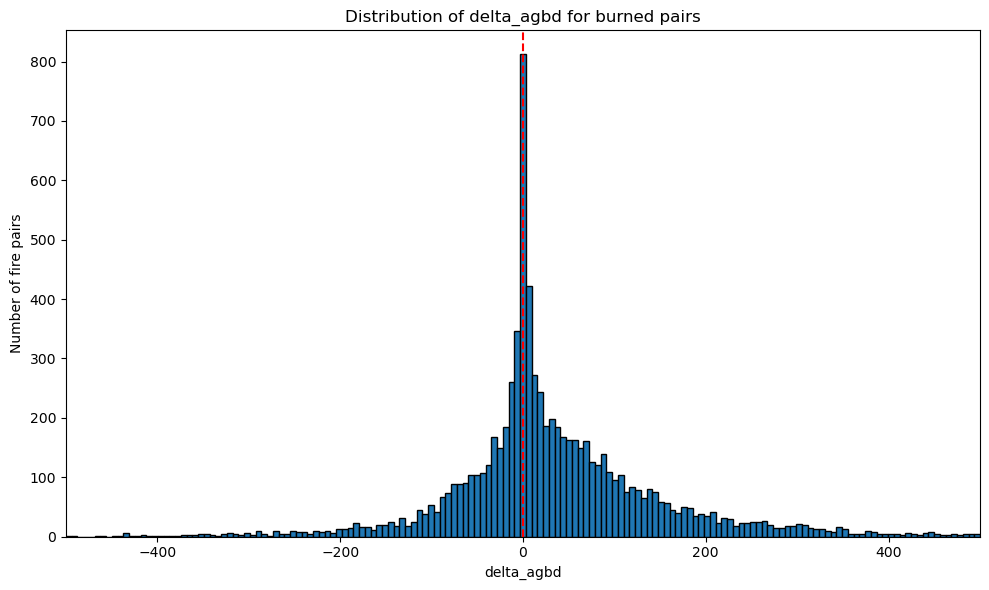

In [47]:
# Keep only values inside the plotting range
delta_for_plot = pairs_fire["delta_agbd"].dropna()
delta_for_plot = delta_for_plot[(delta_for_plot >= -500) & (delta_for_plot <= 500)]

# Define bins between -1000 and 1000
bins = np.linspace(-500, 500, 160)  # 80 bins

plt.figure(figsize=(10, 6))
plt.hist(delta_for_plot, bins=bins, edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)

plt.xlim(-500, 500)
plt.xlabel("delta_agbd")
plt.ylabel("Number of fire pairs")
plt.title("Distribution of delta_agbd for burned pairs")
plt.tight_layout()
plt.show()


In [48]:
OUTPUT_FILE = os.path.join(PAIRS_FOLDER, "GEDI_Footprint_Fire_Pairs.gpkg")

pairs_fire.to_file(OUTPUT_FILE, driver="GPKG")